# LSTM Model Training for WESAD Dataset (64Hz Sampling Rate)

This notebook trains an LSTM model to classify stress, amusement, and baseline states using the WESAD dataset.

In [5]:
import os
import pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.signal import resample_poly, find_peaks, butter, filtfilt
import glob
import pandas as pd

## 1. Configuration and Setup

In [6]:
# Configuration
DATASET_PATH = '/home/binghin2/Myproject/Dataset/WESAD'
TRAIN_USERS = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14']
VAL_USERS = ['S13', 'S14'] # Using S13 and S14 for validation to ensure no data leakage
TEST_USERS = ['S15', 'S16', 'S17']
TARGET_LABELS = {1: 0, 2: 1, 3: 2} # 1: baseline, 2: stress, 3: amusement -> 0, 1, 2
N_FEATURES = 10 # ACC (3), BVP (1), SCL (1), SCR (1), TEMP (1), HR (1), IBI (1), HRV (1)
DOWNSAMPLE_RATE = 64 # Hz, the rate to downsample all signals to
WINDOW_SIZE_SEC = 60 # seconds # 0~60, 1~61 , 2~62 
TRAIN_STRIDE_SEC = 10 # default seconds for training (used when dynamic stride is disabled)
TEST_STRIDE_SEC = 60 # seconds (no overlap for evaluation)
LABEL_PURITY_THRESHOLD = 0.8 # Keep only windows where dominant label ratio >= 80%

# Dynamic stride for training windows (raw labels: 1=baseline, 2=stress, 3=amusement)
TRAIN_DYNAMIC_STRIDE_MAP = {
    1: 15,  # baseline -> sparse sampling
    2: 10,  # stress -> normal sampling
    3: 5    # amusement -> dense sampling (oversampling)
}

# LSTM Hyperparameters
HIDDEN_DIM = 128
LAYER_DIM = 2
OUTPUT_DIM = len(TARGET_LABELS)
BATCH_SIZE = 64
NUM_EPOCHS = 50
LEARNING_RATE = 0.0005
DROPOUT = 0.5

# Setup device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda:0


## 2. Data Loading and Preprocessing

In [7]:
def _to_2d_column(signal):
    """Ensures signal is 2D: (time, channels)."""
    signal = np.asarray(signal)
    if signal.ndim == 1:
        return signal.reshape(-1, 1)
    return signal

def _resample_signal(signal, orig_rate, target_rate):
    """Anti-aliasing resampling using polyphase filtering."""
    signal_2d = _to_2d_column(signal)
    if orig_rate == target_rate:
        return signal_2d
    return resample_poly(signal_2d, up=target_rate, down=orig_rate, axis=0)

def decompose_eda_scl_scr(eda, fs=4, cutoff_hz=0.05, order=2):
    """Decompose EDA into SCL (tonic) and SCR (phasic)."""
    eda_flat = np.asarray(eda).reshape(-1).astype(float)
    nyq = 0.5 * fs
    normalized_cutoff = cutoff_hz / nyq
    b, a = butter(order, normalized_cutoff, btype='low')

    if len(eda_flat) <= (max(len(a), len(b)) * 3):
        scl = np.copy(eda_flat)
    else:
        scl = filtfilt(b, a, eda_flat)

    scr = eda_flat - scl
    return scl.reshape(-1, 1), scr.reshape(-1, 1)

def extract_bvp_features(bvp, orig_rate=64, target_rate=64):
    """
    Extract HR, IBI, and HRV from raw BVP and interpolate them to target_rate.
    Returns shape: (N, 3) -> [HR, IBI, HRV]
    """
    bvp_flat = np.asarray(bvp).flatten()

    min_distance = int(orig_rate * 0.3)
    peaks, _ = find_peaks(bvp_flat, distance=min_distance)

    times_orig = np.arange(len(bvp_flat)) / float(orig_rate)
    target_len = int(np.ceil(len(bvp_flat) * target_rate / float(orig_rate)))
    times_target = np.arange(target_len) / float(target_rate)

    if len(peaks) > 1:
        peak_times = times_orig[peaks]
        ibi = np.diff(peak_times)
        hr = 60.0 / np.clip(ibi, 1e-6, None)
        peak_times = peak_times[1:]

        hr_continuous = np.interp(times_target, peak_times, hr)
        ibi_continuous = np.interp(times_target, peak_times, ibi)

        ibi_series = pd.Series(ibi_continuous)
        hrv_continuous = (
            ibi_series
            .rolling(window=target_rate * 10, min_periods=1)
            .std()
            .fillna(0.0)
            .values
        )
    else:
        hr_continuous = np.zeros(target_len)
        ibi_continuous = np.zeros(target_len)
        hrv_continuous = np.zeros(target_len)

    hr_continuous = hr_continuous.reshape(-1, 1)
    ibi_continuous = ibi_continuous.reshape(-1, 1)
    hrv_continuous = hrv_continuous.reshape(-1, 1)

    return np.concatenate([hr_continuous, ibi_continuous, hrv_continuous], axis=1)

def load_and_preprocess_data(subject_path):
    """Loads data, extracts BVP/EDA features, resamples, synchronizes, and normalizes."""
    with open(subject_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    # --- Extract Wrist Data --- #
    wrist_data = data['signal']['wrist']
    acc = wrist_data['ACC']      # 32 Hz, shape: (T, 3)
    bvp = wrist_data['BVP']      # 64 Hz, shape: (T,) or (T, 1)
    eda = wrist_data['EDA']      # 4 Hz,  shape: (T,) or (T, 1)
    temp = wrist_data['TEMP']    # 4 Hz,  shape: (T,) or (T, 1)
    labels = data['label']       # 700 Hz

    # Extract HR/IBI/HRV from raw 64 Hz BVP before downsampling
    bvp_features = extract_bvp_features(bvp, orig_rate=64, target_rate=DOWNSAMPLE_RATE)

    # Decompose EDA(4Hz) -> SCL/SCR before downsampling
    scl_eda, scr_eda = decompose_eda_scl_scr(eda, fs=4, cutoff_hz=0.05, order=2)

    # --- Resample raw signals to DOWNSAMPLE_RATE --- #
    acc_down = _resample_signal(acc, orig_rate=32, target_rate=DOWNSAMPLE_RATE)
    bvp_down = _resample_signal(bvp, orig_rate=64, target_rate=DOWNSAMPLE_RATE)
    scl_down = _resample_signal(scl_eda, orig_rate=4, target_rate=DOWNSAMPLE_RATE)
    scr_down = _resample_signal(scr_eda, orig_rate=4, target_rate=DOWNSAMPLE_RATE)
    temp_down = _resample_signal(temp, orig_rate=4, target_rate=DOWNSAMPLE_RATE)

    # Align labels by nearest timestamp (categorical label -> no interpolation)
    label_timestamps = np.arange(len(labels)) / 700.0
    data_timestamps = np.arange(len(acc_down)) / float(DOWNSAMPLE_RATE)
    idx = np.searchsorted(label_timestamps, data_timestamps, side='left')
    idx = np.clip(idx, 0, len(labels) - 1)
    labels_down = labels[idx].astype(int)

    # Find minimum common length and truncate
    min_len = min(
        len(acc_down), len(bvp_down), len(scl_down), len(scr_down), len(temp_down), len(bvp_features), len(labels_down)
    )

    # --- Combine Features --- #
    features = np.concatenate([
        acc_down[:min_len],
        bvp_down[:min_len],
        scl_down[:min_len],
        scr_down[:min_len],
        temp_down[:min_len],
        bvp_features[:min_len]
    ], axis=1)

    # --- Subject-wise normalization --- #
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)

    labels_final = labels_down[:min_len]

    return features_scaled, labels_final

def create_windows(features, labels, stride_sec, dynamic_stride_map=None, apply_dynamic_stride=False):
    """Creates sliding windows and keeps only label-pure windows.

    - Fixed mode: uses stride_sec for all windows.
    - Dynamic mode: stride is selected by dominant raw label in each window.
    """
    window_samples = WINDOW_SIZE_SEC * DOWNSAMPLE_RATE
    default_stride_samples = max(1, int(stride_sec * DOWNSAMPLE_RATE))

    X, y = [], []
    i = 0
    max_start = len(features) - window_samples

    while i <= max_start:
        window_features = features[i : i + window_samples]
        window_labels = labels[i : i + window_samples].astype(int)

        counts = np.bincount(window_labels)
        if counts.size == 0:
            i += default_stride_samples
            continue

        most_frequent_label = int(counts.argmax())
        label_purity = counts[most_frequent_label] / float(window_samples)

        if most_frequent_label in TARGET_LABELS and label_purity >= LABEL_PURITY_THRESHOLD:
            X.append(window_features)
            y.append(TARGET_LABELS[most_frequent_label])

        if apply_dynamic_stride and dynamic_stride_map is not None:
            stride_next_sec = dynamic_stride_map.get(most_frequent_label, stride_sec)
            stride_next_samples = max(1, int(stride_next_sec * DOWNSAMPLE_RATE))
        else:
            stride_next_samples = default_stride_samples

        i += stride_next_samples

    return np.array(X), np.array(y)

In [8]:
# --- Process TRAIN users (overlap allowed). Skip users reserved for VAL/TEST --- #
train_X, train_y = [], []
for user in TRAIN_USERS:
    if user in VAL_USERS or user in TEST_USERS:
        print(f'Skipping user {user} (reserved for VAL/TEST)')
        continue
    subject_path = os.path.join(DATASET_PATH, user, f'{user}.pkl')
    if os.path.exists(subject_path):
        print(f'Processing TRAIN user: {user}...')
        features, labels = load_and_preprocess_data(subject_path)
        X_user, y_user = create_windows(
            features,
            labels,
            stride_sec=TRAIN_STRIDE_SEC,
            dynamic_stride_map=TRAIN_DYNAMIC_STRIDE_MAP,
            apply_dynamic_stride=True
        )
        if X_user.size > 0:
            train_X.append(X_user)
            train_y.append(y_user)

if len(train_X) == 0:
    raise ValueError('No training data found. Check TRAIN_USERS or DATASET_PATH.')

X_train = np.concatenate(train_X, axis=0)
y_train = np.concatenate(train_y, axis=0)

print(f'\nTotal TRAIN windows created: {len(X_train)}')
print(f'TRAIN feature shape: {X_train.shape}')
print(f'TRAIN label distribution: {np.bincount(y_train)}')

# --- Process VAL users (no overlap by default using TEST_STRIDE_SEC) --- #
val_X, val_y = [], []
for user in VAL_USERS:
    subject_path = os.path.join(DATASET_PATH, user, f'{user}.pkl')
    if os.path.exists(subject_path):
        print(f'Processing VAL user: {user}...')
        features, labels = load_and_preprocess_data(subject_path)
        X_user, y_user = create_windows(features, labels, stride_sec=TEST_STRIDE_SEC)
        if X_user.size > 0:
            val_X.append(X_user)
            val_y.append(y_user)

if len(val_X) == 0:
    raise ValueError('No validation data found. Check VAL_USERS or DATASET_PATH.')

X_val = np.concatenate(val_X, axis=0)
y_val = np.concatenate(val_y, axis=0)

print(f'\nTotal VAL windows created: {len(X_val)}')
print(f'VAL feature shape: {X_val.shape}')
print(f'VAL label distribution: {np.bincount(y_val)}')

# --- Process TEST users (non-overlapping windows) --- #
test_X, test_y = [], []
for user in TEST_USERS:
    subject_path = os.path.join(DATASET_PATH, user, f'{user}.pkl')
    if os.path.exists(subject_path):
        print(f'Processing TEST user: {user}...')
        features, labels = load_and_preprocess_data(subject_path)
        X_user, y_user = create_windows(features, labels, stride_sec=TEST_STRIDE_SEC)
        if X_user.size > 0:
            test_X.append(X_user)
            test_y.append(y_user)

if len(test_X) == 0:
    raise ValueError('No test data found. Check TEST_USERS or DATASET_PATH.')

X_test = np.concatenate(test_X, axis=0)
y_test = np.concatenate(test_y, axis=0)

print(f'\nTest set size: {len(X_test)}')
print(f'TEST feature shape: {X_test.shape}')
print(f'TEST label distribution: {np.bincount(y_test)}')

# Subject-wise normalization is already applied in load_and_preprocess_data()

Processing TRAIN user: S2...
Processing TRAIN user: S3...
Processing TRAIN user: S4...
Processing TRAIN user: S5...
Processing TRAIN user: S6...
Processing TRAIN user: S7...
Processing TRAIN user: S8...
Processing TRAIN user: S9...
Processing TRAIN user: S10...
Processing TRAIN user: S11...
Skipping user S13 (reserved for VAL/TEST)
Skipping user S14 (reserved for VAL/TEST)

Total TRAIN windows created: 2041
TRAIN feature shape: (2041, 3840, 10)
TRAIN label distribution: [758 616 667]
Processing VAL user: S13...
Processing VAL user: S14...

Total VAL windows created: 71
VAL feature shape: (71, 3840, 10)
VAL label distribution: [38 21 12]
Processing TEST user: S15...
Processing TEST user: S16...
Processing TEST user: S17...

Test set size: 108
TEST feature shape: (108, 3840, 10)
TEST label distribution: [57 33 18]


## 3. PyTorch Dataset and DataLoader

In [9]:
class WesadDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = WesadDataset(X_train, y_train)
val_dataset = WesadDataset(X_val, y_val)
test_dataset = WesadDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## 4. LSTM Model Definition

In [10]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        
        # Use nn.LSTM which is more standard and efficient
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True, dropout=DROPOUT)
        
        # Fully connected layer
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # Initialize hidden and cell states
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(device).requires_grad_()
        c0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(device).requires_grad_()
        
        # We need to detach as we are doing truncated backpropagation through time (BPTT)
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        
        # Index hidden state of last time step
        out = self.fc(out[:, -1, :]) 
        return out

## 5. Model Training

In [11]:
from sklearn.metrics import f1_score

class FocalLoss(nn.Module):
    """Multi-class Focal Loss with optional per-class alpha weights."""
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = nn.functional.cross_entropy(
            logits,
            targets,
            weight=self.alpha,
            reduction='none'
        )
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        if self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

model = LSTMModel(N_FEATURES, HIDDEN_DIM, LAYER_DIM, OUTPUT_DIM)
model.to(device)

# Class weights (inverse frequency) + Focal Loss
class_counts = np.bincount(y_train, minlength=OUTPUT_DIM).astype(np.float32)
class_counts = np.clip(class_counts, a_min=1.0, a_max=None)
class_weights_np = 1.0 / class_counts
class_weights_np = class_weights_np / class_weights_np.sum()
class_weights = torch.tensor(class_weights_np, dtype=torch.float32, device=device)
print(f"Class counts (train): {class_counts.astype(int)}")
print(f"Class weights       : {class_weights_np}")

FOCAL_GAMMA = 2.0
criterion = FocalLoss(alpha=class_weights, gamma=FOCAL_GAMMA, reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Early Stopping 설정 (Validation Macro F1 기준)
PATIENCE = 10
MIN_DELTA = 1e-4
best_val_macro_f1 = -float("inf")
epochs_no_improve = 0
best_model_state = None

print("Starting training with Focal Loss + Macro-F1 Early Stopping...")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for i, (sequences, labels) in enumerate(train_loader):
        sequences = sequences.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(sequences)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * sequences.size(0)

        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_acc = (correct_predictions / total_samples) * 100

    # Validation
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for sequences, labels in val_loader:
            sequences = sequences.to(device)
            labels = labels.to(device)

            outputs = model(sequences)
            val_loss = criterion(outputs, labels)

            val_running_loss += val_loss.item() * sequences.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            val_preds.extend(predicted.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_epoch_loss = val_running_loss / val_total
    val_epoch_acc = (val_correct / val_total) * 100
    val_epoch_macro_f1 = f1_score(val_labels, val_preds, average='macro', zero_division=0)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}% | "
        f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.2f}%, Val Macro F1: {val_epoch_macro_f1:.4f}"
    )

    # Early Stopping 체크 (Validation Macro F1 기준)
    if val_epoch_macro_f1 > best_val_macro_f1 + MIN_DELTA:
        best_val_macro_f1 = val_epoch_macro_f1
        best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
        print(f"  ✅ Validation Macro F1 improved. Best Val Macro F1: {best_val_macro_f1:.4f}")
    else:
        epochs_no_improve += 1
        print(f"  ⏳ No Macro F1 improvement for {epochs_no_improve}/{PATIENCE} epoch(s)")

        if epochs_no_improve >= PATIENCE:
            print(f"\n🛑 Early stopping triggered at epoch {epoch+1}")
            break

# best weight 복원
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    model.to(device)
    print(f"✅ Loaded best model weights (Best Val Macro F1: {best_val_macro_f1:.4f})")

Class counts (train): [758 616 667]
Class weights       : [0.29700458 0.3654699  0.33752546]
Starting training with Focal Loss + Macro-F1 Early Stopping...
Epoch [1/50] | Train Loss: 0.0252, Train Acc: 66.19% | Val Loss: 0.0213, Val Acc: 39.44%, Val Macro F1: 0.3991
  ✅ Validation Macro F1 improved. Best Val Macro F1: 0.3991
Epoch [2/50] | Train Loss: 0.0092, Train Acc: 80.11% | Val Loss: 0.0441, Val Acc: 39.44%, Val Macro F1: 0.3836
  ⏳ No Macro F1 improvement for 1/10 epoch(s)
Epoch [3/50] | Train Loss: 0.0071, Train Acc: 86.62% | Val Loss: 0.0571, Val Acc: 45.07%, Val Macro F1: 0.4560
  ✅ Validation Macro F1 improved. Best Val Macro F1: 0.4560
Epoch [4/50] | Train Loss: 0.0060, Train Acc: 87.60% | Val Loss: 0.0561, Val Acc: 47.89%, Val Macro F1: 0.4995
  ✅ Validation Macro F1 improved. Best Val Macro F1: 0.4995
Epoch [5/50] | Train Loss: 0.0054, Train Acc: 88.39% | Val Loss: 0.0471, Val Acc: 45.07%, Val Macro F1: 0.4727
  ⏳ No Macro F1 improvement for 1/10 epoch(s)
Epoch [6/50] | Tr

In [12]:
# 학습 완료 후 모델 저장
SAVE_DIR = r"C:\Users\mbnv6\Project\Research\WESAD_classification\Training\Save_model\LSTM"

os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_SAVE_PATH = os.path.join(SAVE_DIR, "LSTM_64hz_model_focal.pt")

checkpoint = {

    "model_name": "LSTM_64HZ",
    "model_state_dict": model.state_dict(),
    "n_features": N_FEATURES,
    "hidden_dim": HIDDEN_DIM,
    "layer_dim": LAYER_DIM,
    "output_dim": OUTPUT_DIM,
}

torch.save(checkpoint, MODEL_SAVE_PATH)
print(f"✅ Model saved to: {MODEL_SAVE_PATH}")

✅ Model saved to: C:\Users\mbnv6\Project\Research\WESAD_classification\Training\Save_model\LSTM/LSTM_64hz_model_focal.pt


## 6. Model Evaluation

In [13]:
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for sequences, labels in test_loader:
        sequences = sequences.to(device)
        labels = labels.to(device)
        
        outputs = model(sequences)
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total
print(f'\nTest Accuracy: {accuracy:.2f} %')

# Optional: Print classification report for more details
try:
    from sklearn.metrics import classification_report
    report = classification_report(all_labels, all_preds, target_names=['baseline', 'stress', 'amusement'])
    print("\nClassification Report:")
    print(report)
except ImportError:
    print("\nPlease install scikit-learn to see the classification report: pip install -U scikit-learn")

# 각 클래스별 정확도 계산
all_labels_np = np.array(all_labels)
all_preds_np = np.array(all_preds)

class_names = ['Baseline', 'Stress', 'Amusement']
print("\n" + "="*60)
print("각 상태별 정확도")
print("="*60)

for class_idx, class_name in enumerate(class_names):
    # 해당 클래스의 샘플들
    class_mask = all_labels_np == class_idx
    class_total = class_mask.sum()
    
    if class_total > 0:
        # 해당 클래스에서 올바르게 예측된 샘플들
        class_correct = ((all_labels_np == class_idx) & (all_preds_np == class_idx)).sum()
        class_accuracy = (class_correct / class_total) * 100
        print(f"{class_name}: {class_accuracy:.2f}% ({class_correct}/{class_total})")
    else:
        print(f"{class_name}: N/A (no samples)")

print("="*60)


Test Accuracy: 75.00 %

Classification Report:
              precision    recall  f1-score   support

    baseline       0.94      0.86      0.90        57
      stress       0.63      0.73      0.68        33
   amusement       0.44      0.44      0.44        18

    accuracy                           0.75       108
   macro avg       0.67      0.68      0.67       108
weighted avg       0.76      0.75      0.76       108


각 상태별 정확도
Baseline: 85.96% (49/57)
Stress: 72.73% (24/33)
Amusement: 44.44% (8/18)


## 7. Data Analysis: Characteristics of Each State

각 상태(Baseline, Stress, Amusement)의 센서 데이터 특징을 분석합니다.

In [14]:
# 한 명의 피험자 데이터를 로드하여 각 상태별 특징 분석
sample_subject = 'S2'
subject_path = os.path.join(DATASET_PATH, sample_subject, f'{sample_subject}.pkl')

with open(subject_path, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

# Extract signals
wrist = data['signal']['wrist']
acc = wrist['ACC']  # Accelerometer (3축)
bvp = wrist['BVP']  # Blood Volume Pulse
eda = wrist['EDA']  # Electrodermal Activity (피부전기활동)
temp = wrist['TEMP']  # Skin Temperature
labels = data['label']

# Downsample to 4Hz
acc_down = acc[::32 // 4]
bvp_down = bvp[::64 // 4]
eda_down = eda[::4 // 4]
temp_down = temp[::4 // 4]
labels_down = labels[::700 // 4]

# Align lengths
min_len = min(len(acc_down), len(bvp_down), len(eda_down), len(temp_down), len(labels_down))
acc_down = acc_down[:min_len]
bvp_down = bvp_down[:min_len]
eda_down = eda_down[:min_len]
temp_down = temp_down[:min_len]
labels_down = labels_down[:min_len].astype(int)

print(f"데이터 길이: {min_len} samples (at 4Hz)")
print(f"레이블 분포: {np.bincount(labels_down)}")
print(f"고유 레이블: {np.unique(labels_down)}")

데이터 길이: 24316 samples (at 4Hz)
레이블 분포: [12244  4576  2460  1448  3072     0   260   256]
고유 레이블: [0 1 2 3 4 6 7]


In [15]:
# 각 상태별 통계 분석
import pandas as pd

states = {1: 'Baseline', 2: 'Stress', 3: 'Amusement'}
stats_list = []

for label_num, label_name in states.items():
    mask = labels_down == label_num
    if mask.sum() > 0:
        # ACC magnitude (3축의 크기)
        acc_mag = np.sqrt(np.sum(acc_down[mask]**2, axis=1))
        
        stats = {
            'State': label_name,
            'Samples': mask.sum(),
            'ACC_X_mean': acc_down[mask][:, 0].mean(),
            'ACC_X_std': acc_down[mask][:, 0].std(),
            'ACC_Y_mean': acc_down[mask][:, 1].mean(),
            'ACC_Y_std': acc_down[mask][:, 1].std(),
            'ACC_Z_mean': acc_down[mask][:, 2].mean(),
            'ACC_Z_std': acc_down[mask][:, 2].std(),
            'ACC_magnitude_mean': acc_mag.mean(),
            'ACC_magnitude_std': acc_mag.std(),
            'BVP_mean': bvp_down[mask].mean(),
            'BVP_std': bvp_down[mask].std(),
            'EDA_mean': eda_down[mask].mean(),
            'EDA_std': eda_down[mask].std(),
            'TEMP_mean': temp_down[mask].mean(),
            'TEMP_std': temp_down[mask].std(),
        }
        stats_list.append(stats)

df_stats = pd.DataFrame(stats_list)
print(f"\n=== {sample_subject} 피험자의 각 상태별 센서 데이터 통계 ===\n")
print(df_stats.to_string(index=False))


=== S2 피험자의 각 상태별 센서 데이터 통계 ===

    State  Samples  ACC_X_mean  ACC_X_std  ACC_Y_mean  ACC_Y_std  ACC_Z_mean  ACC_Z_std  ACC_magnitude_mean  ACC_magnitude_std  BVP_mean   BVP_std  EDA_mean  EDA_std  TEMP_mean  TEMP_std
 Baseline     4576   48.946897  12.729897   18.508960  10.970315    6.521635  31.077995           63.403876           3.016676 -0.358011 64.911004  0.297881 0.309248  35.786198  0.108444
   Stress     2460   17.187805   6.017496  -58.593902   3.004016   13.711789   3.959277           63.010803           2.688511 -0.635020 76.083655  0.870277 0.204461  33.442098  0.462643
Amusement     1448   51.100138  16.322088   16.600829  25.646897   -7.921271  11.424960           63.258529           1.618727 -0.199344 48.090798  0.206203 0.038276  34.190884  0.120213


In [16]:
# 주요 특징 비교 (상대적 변화율)
print("\n=== 주요 센서 특징 비교 (Baseline 대비) ===\n")
baseline_idx = df_stats[df_stats['State'] == 'Baseline'].index[0]

for metric in ['BVP_mean', 'EDA_mean', 'TEMP_mean', 'ACC_magnitude_mean']:
    print(f"\n{metric}:")
    baseline_val = df_stats.loc[baseline_idx, metric]
    for idx, row in df_stats.iterrows():
        if row['State'] != 'Baseline':
            change = ((row[metric] - baseline_val) / baseline_val) * 100
            print(f"  {row['State']}: {row[metric]:.4f} (Baseline 대비 {change:+.2f}%)")
        else:
            print(f"  {row['State']}: {row[metric]:.4f} (기준)")


=== 주요 센서 특징 비교 (Baseline 대비) ===


BVP_mean:
  Baseline: -0.3580 (기준)
  Stress: -0.6350 (Baseline 대비 +77.37%)
  Amusement: -0.1993 (Baseline 대비 -44.32%)

EDA_mean:
  Baseline: 0.2979 (기준)
  Stress: 0.8703 (Baseline 대비 +192.16%)
  Amusement: 0.2062 (Baseline 대비 -30.78%)

TEMP_mean:
  Baseline: 35.7862 (기준)
  Stress: 33.4421 (Baseline 대비 -6.55%)
  Amusement: 34.1909 (Baseline 대비 -4.46%)

ACC_magnitude_mean:
  Baseline: 63.4039 (기준)
  Stress: 63.0108 (Baseline 대비 -0.62%)
  Amusement: 63.2585 (Baseline 대비 -0.23%)


/tmp/ipykernel_17424/602739894.py:28: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17424/602739894.py:28: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17424/602739894.py:28: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17424/602739894.py:28: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17424/602739894.py:28: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17424/602739894.py:28: UserWarning: Glyph 53468 (\N{HANGUL SYLLABLE TAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17424/602739894.py:28: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_

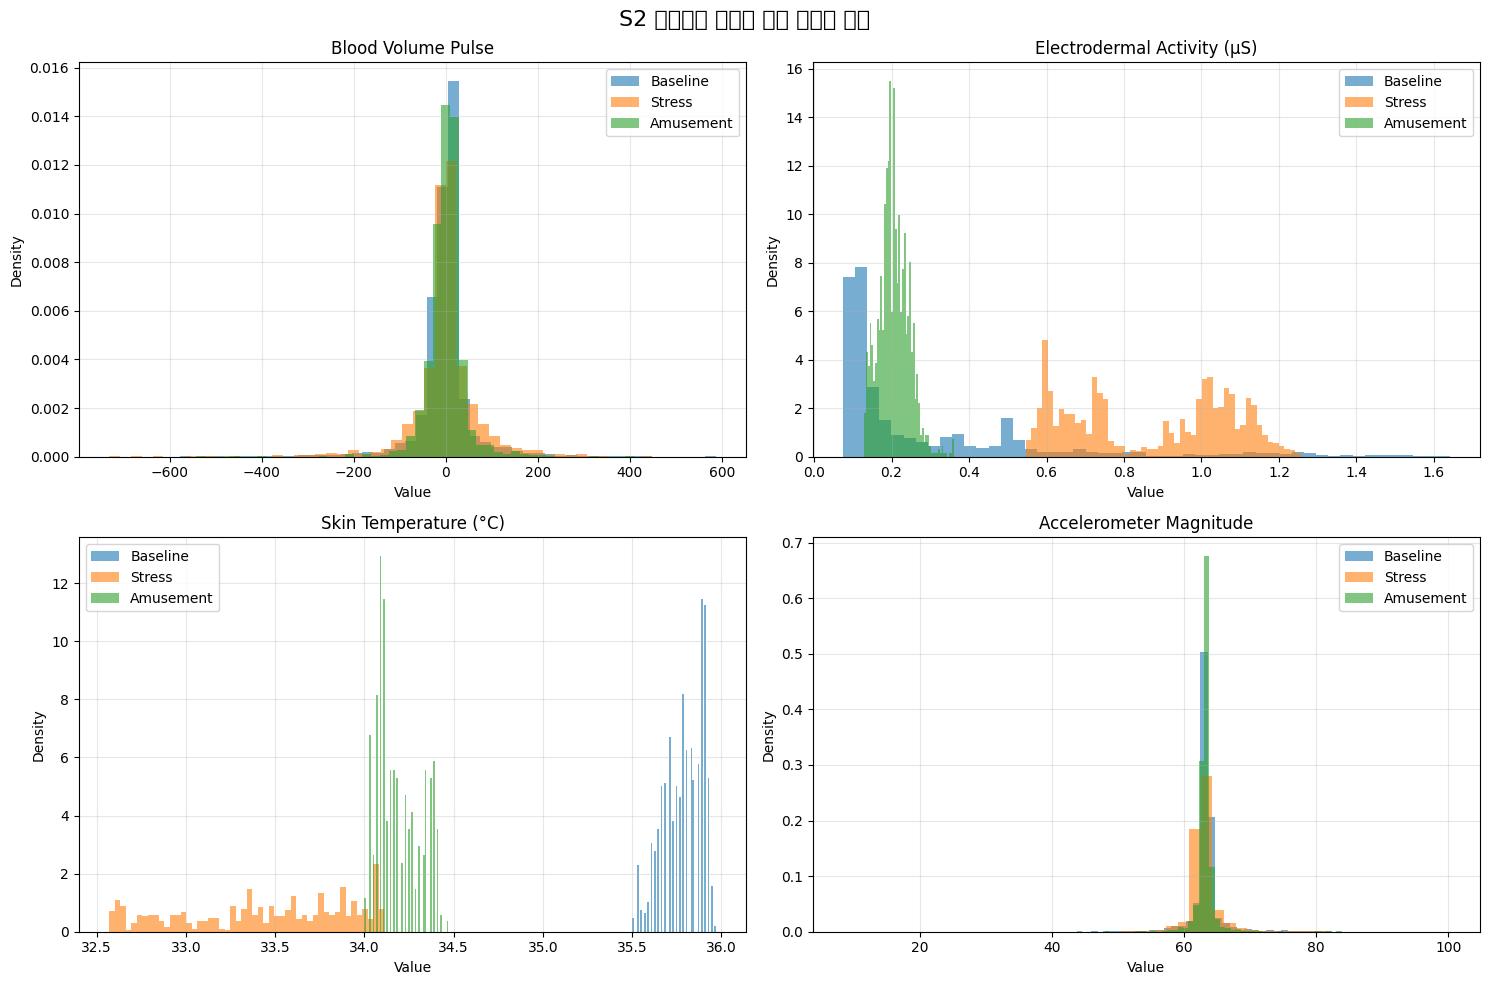

In [17]:
# 시각화: 각 상태별 센서 데이터 분포
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'{sample_subject} 피험자의 상태별 센서 데이터 분포', fontsize=16)

sensors = [
    ('BVP', bvp_down, 'Blood Volume Pulse'),
    ('EDA', eda_down, 'Electrodermal Activity (μS)'),
    ('TEMP', temp_down, 'Skin Temperature (°C)'),
    ('ACC_mag', np.sqrt(np.sum(acc_down**2, axis=1)), 'Accelerometer Magnitude')
]

for idx, (sensor_name, sensor_data, title) in enumerate(sensors):
    ax = axes[idx // 2, idx % 2]
    
    for label_num, label_name in states.items():
        mask = labels_down == label_num
        if mask.sum() > 0:
            ax.hist(sensor_data[mask], bins=50, alpha=0.6, label=label_name, density=True)
    
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_17424/2191540109.py:39: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17424/2191540109.py:39: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17424/2191540109.py:39: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17424/2191540109.py:39: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17424/2191540109.py:39: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17424/2191540109.py:39: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17424/2191540109.py:39: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.t

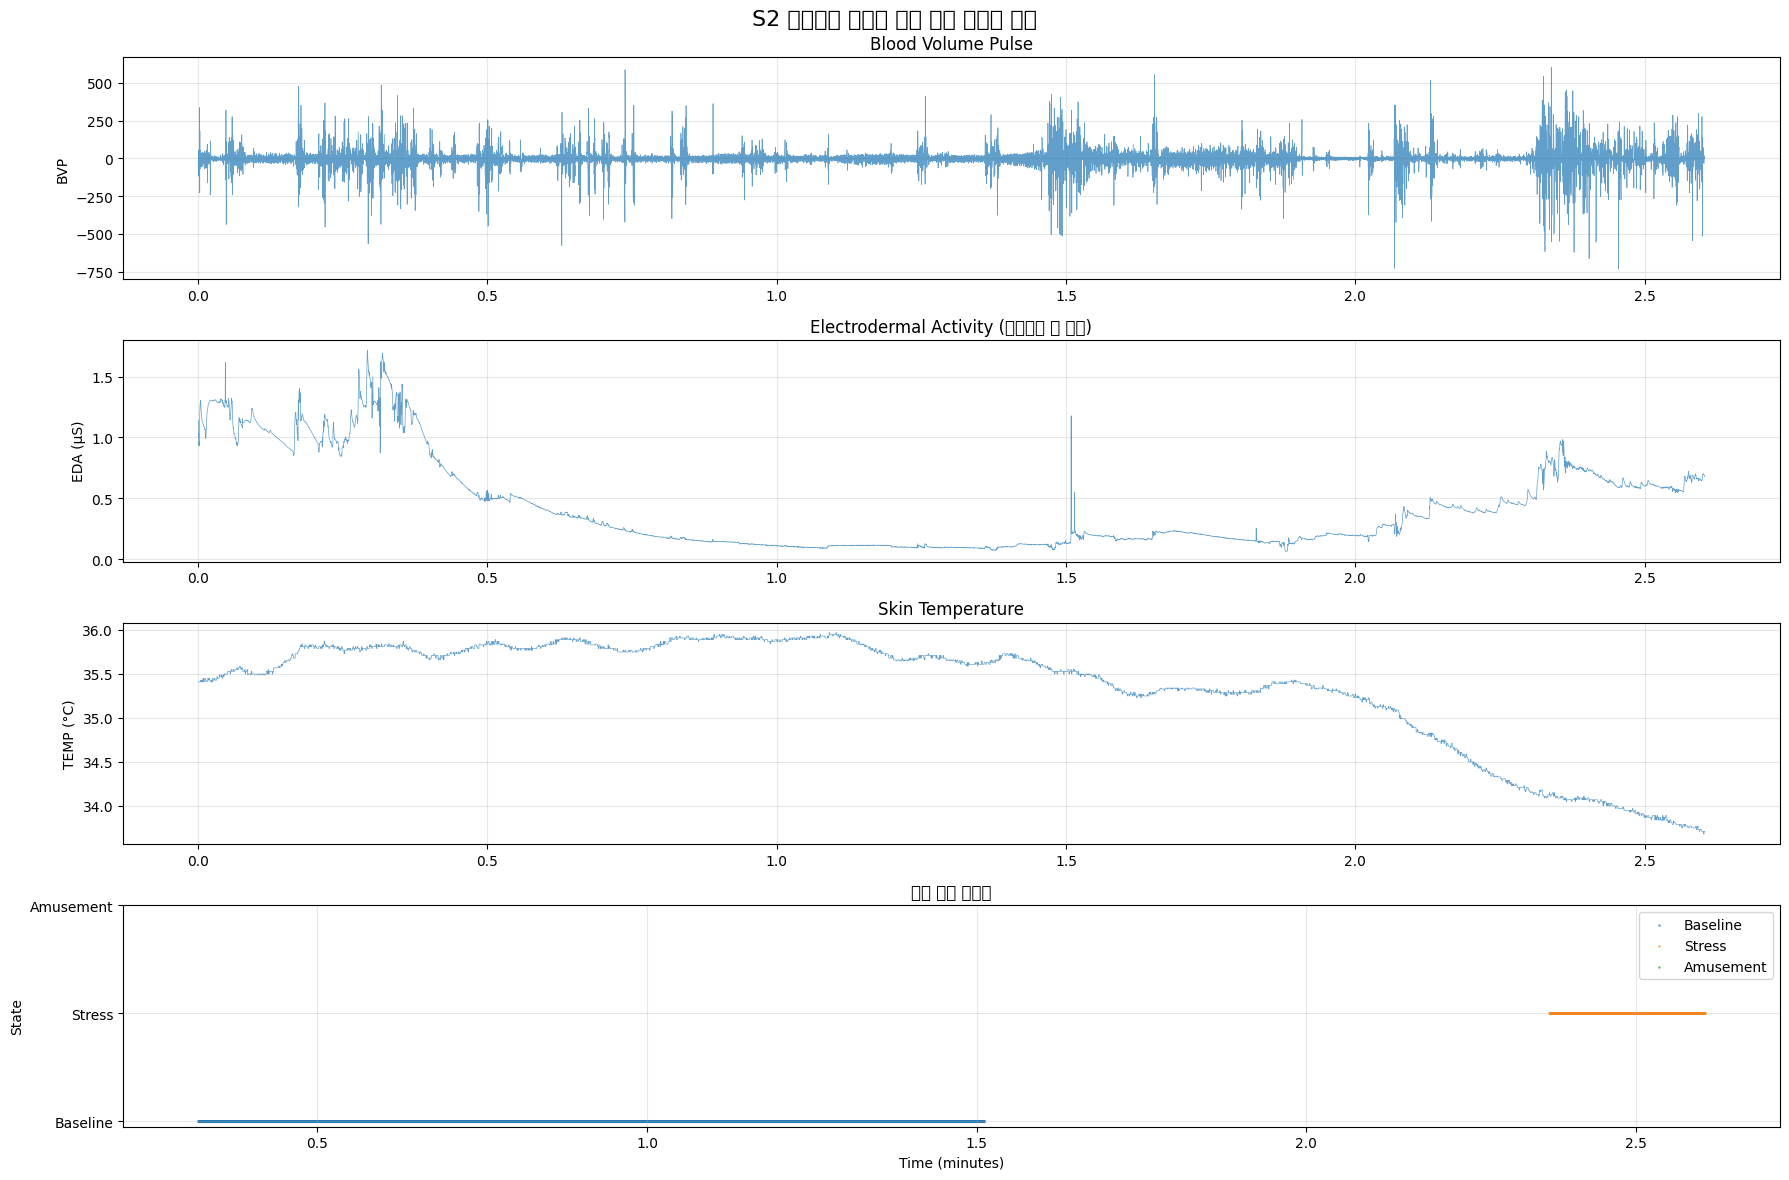

In [18]:
# 시계열 시각화: 각 상태의 센서 데이터 변화 패턴
fig, axes = plt.subplots(4, 1, figsize=(18, 12))
fig.suptitle(f'{sample_subject} 피험자의 시간에 따른 센서 데이터 변화', fontsize=16)

# 전체 데이터의 일부만 시각화 (처음 10000 samples, 약 40분)
plot_len = min(10000, len(labels_down))
time_axis = np.arange(plot_len) / DOWNSAMPLE_RATE / 60  # minutes

# BVP
axes[0].plot(time_axis, bvp_down[:plot_len, 0], linewidth=0.5, alpha=0.7)
axes[0].set_ylabel('BVP')
axes[0].set_title('Blood Volume Pulse')
axes[0].grid(True, alpha=0.3)

# EDA
axes[1].plot(time_axis, eda_down[:plot_len, 0], linewidth=0.5, alpha=0.7)
axes[1].set_ylabel('EDA (μS)')
axes[1].set_title('Electrodermal Activity (스트레스 시 증가)')
axes[1].grid(True, alpha=0.3)

# TEMP
axes[2].plot(time_axis, temp_down[:plot_len, 0], linewidth=0.5, alpha=0.7)
axes[2].set_ylabel('TEMP (°C)')
axes[2].set_title('Skin Temperature')
axes[2].grid(True, alpha=0.3)

# Labels (상태)
for label_num, label_name in states.items():
    mask = labels_down[:plot_len] == label_num
    axes[3].scatter(time_axis[mask], [label_num]*mask.sum(), s=1, alpha=0.5, label=label_name)
axes[3].set_ylabel('State')
axes[3].set_xlabel('Time (minutes)')
axes[3].set_title('실험 상태 레이블')
axes[3].set_yticks([1, 2, 3])
axes[3].set_yticklabels(['Baseline', 'Stress', 'Amusement'])
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 각 상태의 생리학적 특징 해석

**🔵 Baseline (기준선)**
- 평상시 안정된 상태
- 모든 센서 값이 안정적이고 변동이 적음
- 참고 기준값

**🔴 Stress (스트레스)**
- **EDA (피부전기활동) ↑**: 스트레스를 받으면 땀샘 활동 증가로 피부 전도도 상승
- **심박수/BVP ↑**: 교감신경 활성화로 심박수 증가
- **피부온도**: 상황에 따라 변동 (긴장 시 손발이 차가워질 수 있음)
- **ACC**: 움직임 패턴 변화 (긴장으로 인한 미세한 움직임)

**🟢 Amusement (즐거움)**
- **BVP**: 리듬이 더 안정적이고 규칙적
- **EDA**: Baseline보다 높을 수 있으나 Stress보다는 낮음
- **피부온도**: 비교적 안정적
- **ACC**: 웃거나 즐거워할 때의 움직임 패턴

In [19]:
# Inference Time Benchmark (LSTM)
import time
import numpy as np
import torch

if "model" not in globals():
    raise NameError("`model` 변수가 없습니다. 모델 생성/학습 셀을 먼저 실행하세요.")
if "test_loader" not in globals():
    raise NameError("`test_loader` 변수가 없습니다. DataLoader 생성 셀을 먼저 실행하세요.")

runtime_device = device if "device" in globals() else torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(runtime_device)
model.eval()


def _sync_if_cuda(dev):
    if dev.type == "cuda":
        torch.cuda.synchronize()


@torch.no_grad()
def benchmark_inference(model, data_loader, dev, warmup_steps=20):
    iterator = iter(data_loader)
    first_batch = next(iterator)
    x0 = first_batch[0].to(dev)

    for _ in range(warmup_steps):
        _ = model(x0)
    _sync_if_cuda(dev)

    batch_times = []
    total_samples = 0

    for inputs, _ in data_loader:
        inputs = inputs.to(dev)

        _sync_if_cuda(dev)
        t0 = time.perf_counter()
        _ = model(inputs)
        _sync_if_cuda(dev)
        t1 = time.perf_counter()

        batch_times.append((t1 - t0) * 1000.0)
        total_samples += inputs.size(0)

    total_time_ms = float(np.sum(batch_times))
    avg_batch_ms = float(np.mean(batch_times))
    std_batch_ms = float(np.std(batch_times))
    avg_sample_ms = total_time_ms / max(total_samples, 1)
    throughput = total_samples / (total_time_ms / 1000.0)

    return {
        "num_batches": len(batch_times),
        "num_samples": total_samples,
        "total_time_ms": total_time_ms,
        "avg_batch_ms": avg_batch_ms,
        "std_batch_ms": std_batch_ms,
        "avg_sample_ms": avg_sample_ms,
        "throughput_sps": throughput,
    }


stats = benchmark_inference(model, test_loader, runtime_device, warmup_steps=20)

print("=" * 70)
print("LSTM Inference Benchmark (Test Loader)")
print("=" * 70)
print(f"Device            : {runtime_device}")
print(f"Batches           : {stats['num_batches']}")
print(f"Samples           : {stats['num_samples']}")
print(f"Total time        : {stats['total_time_ms']:.2f} ms")
print(f"Avg batch latency : {stats['avg_batch_ms']:.3f} ± {stats['std_batch_ms']:.3f} ms")
print(f"Avg sample latency: {stats['avg_sample_ms']:.4f} ms/sample")
print(f"Throughput        : {stats['throughput_sps']:.2f} samples/sec")

LSTM Inference Benchmark (Test Loader)
Device            : cuda:0
Batches           : 2
Samples           : 108
Total time        : 30.07 ms
Avg batch latency : 15.037 ± 0.461 ms
Avg sample latency: 0.2785 ms/sample
Throughput        : 3591.20 samples/sec


In [20]:
# 실시간 환경(Batch Size 1)을 위한 전용 로더 생성
realtime_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# 기존의 벤치마크 함수를 그대로 사용하여 측정
stats_rt = benchmark_inference(model, realtime_loader, runtime_device, warmup_steps=50)

print("=" * 70)
print("실시간 응답 시간 측정 결과 (Batch Size = 1)")
print("=" * 70)
print(f"Device            : {runtime_device}")
print(f"순수 모델 응답 시간 : {stats_rt['avg_batch_ms']:.3f} ms") 
print(f"초당 처리 가능 횟수 : {stats_rt['throughput_sps']:.2f} FPS")
print("=" * 70)

실시간 응답 시간 측정 결과 (Batch Size = 1)
Device            : cuda:0
순수 모델 응답 시간 : 12.782 ms
초당 처리 가능 횟수 : 78.23 FPS
